In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("df.info")
print(df.info())
print("df.describe")
print(df.describe())
print("df.head")
print(df.head())

print(f"Före rengöring: {len(df)} rader")
print(f"Saknade värden:\n{df.isnull().sum()}")


df.info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   

In [3]:
df["TotalCharges"] = (
    df["TotalCharges"]
    .str.replace(" ", "0", regex=False)
    .astype(float)
)

In [4]:
# df.to_excel("output.xlsx")

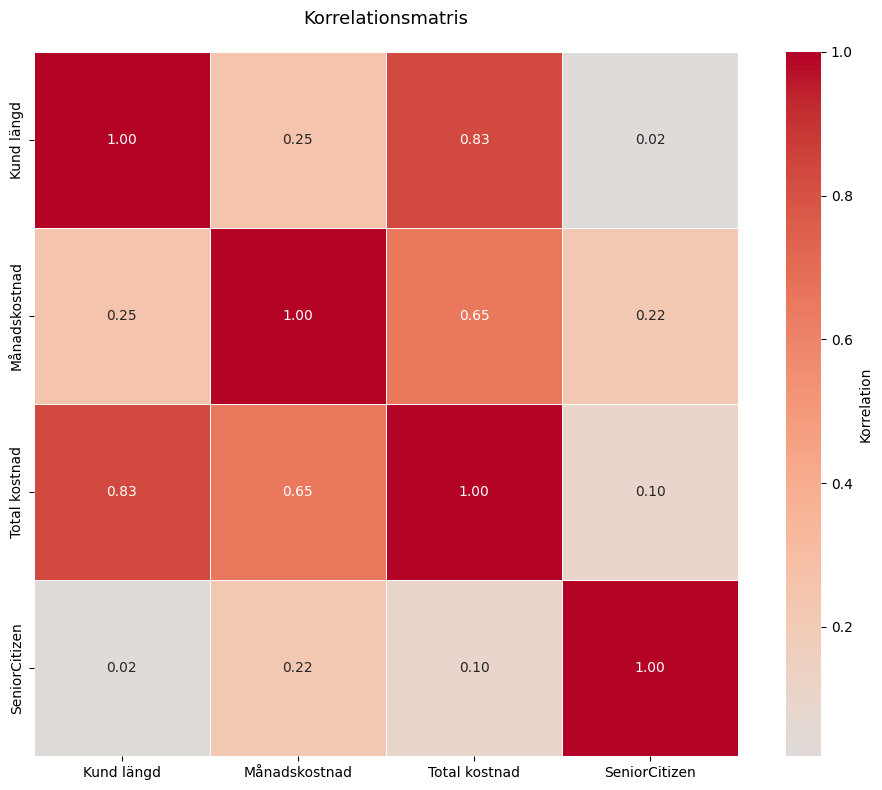

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Välj relevanta numeriska kolumner
cols_heatmap = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen'
]

# Beräkna korrelationsmatris
corr = df[cols_heatmap].corr().round(2)

# Svenska kolumnnamn
corr.columns = [
    'Kund längd',
    'Månadskostnad', 
    'Total kostnad',
    'SeniorCitizen'
]
corr.index = corr.columns

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Korrelation'}
)
plt.title('Korrelationsmatris', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

In [6]:
# 1. Kolla att det inte finns några konstigheter kvar
print(df['TotalCharges'].dtype)        # ska nu vara float64
print(df['TotalCharges'].isna().sum()) # ska vara 0
print(df['TotalCharges'].describe())

# 2. Sanity check: TotalCharges borde ungefär vara tenure * MonthlyCharges
df['expected'] = df['tenure'] * df['MonthlyCharges']
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'expected']].head(10)

float64
0
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


,tenure,MonthlyCharges,TotalCharges,expected
0,1,29.85,29.85,29.85
1,34,56.95,1889.50,1936.30
2,2,53.85,108.15,107.70
3,45,42.30,1840.75,1903.50
4,2,70.70,151.65,141.40
5,8,99.65,820.50,797.20
6,22,89.10,1949.40,1960.20
7,10,29.75,301.90,297.50
8,28,104.80,3046.05,2934.40
9,62,56.15,3487.95,3481.30


In [7]:
df = df.drop(columns=['expected'])

In [8]:
# Lista alla object-kolumner och deras unika värden
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')  # ID är inte en feature

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [9]:
# Gruppera kolumnerna
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    df[col] = df[col].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Verifiera
for col in internet_cols + ['MultipleLines']:
    print(f"{col}: {df[col].unique()}")

OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
MultipleLines: ['No' 'Yes']


In [10]:
# Konvertera Churn till binära värden från No/Yes
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
# df = hela datasetet, behåller customerID för uppslagning, debugging, presentation
# y  = målvariabel
# X  = bara features som går in i modellen (utan ID och utan target)

y = df['Churn']
X = df.drop(columns=['customerID', 'Churn'])

print(f"X shape: {X.shape}")  # (7043, 19)
print(f"y shape: {y.shape}")  # (7043,)
print(f"df shape (orörd): {df.shape}")  # (7043, 21)

X shape: (7043, 19)
y shape: (7043,)
df shape (orörd): (7043, 21)


In [12]:
# Vi sparar originalet (utan dummies) – kan vara värt att ha kvar till sen!
X_orig = X.copy()

X = pd.get_dummies(X, drop_first=True, dtype=int)

print(f"X shape efter dummy: {X.shape}")
print(X.dtypes.value_counts())

X shape efter dummy: (7043, 23)
int64      21
float64     2
Name: count, dtype: int64


In [13]:
# Kolla hur det blev med get_dummies
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0            1               0                 0                  0   
1            0               0                 1                  0   
2            0               0                 1                  0   
3            0               0                 0                  0   
4            0               0                 1                  0   

   InternetService_Fiber optic  ...  DeviceProtection_Yes  TechSupport_Yes  \
0                            0  ...                     0           

In [14]:
# Nu delar vi på datasetet i tränings- och testdata med en 70/30 split, då vi har relativt mycket data
# stratify=y tvingar train_test_split att bevara proportionerna av målvariabeln i både train och test.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print()
print("Andel churn i train:", y_train.mean().round(3))
print("Andel churn i test: ", y_test.mean().round(3))

X_train: (4930, 23), y_train: (4930,)
X_test:  (2113, 23), y_test:  (2113,)

Andel churn i train: 0.265
Andel churn i test:  0.265


C:\Users\ES7233\AppData\Local\Temp\ipykernel_2520\1950109889.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['steelblue', 'coral'])
C:\Users\ES7233\AppData\Local\Temp\ipykernel_2520\1950109889.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No (kvar)', 'Yes (uppsagt)'])


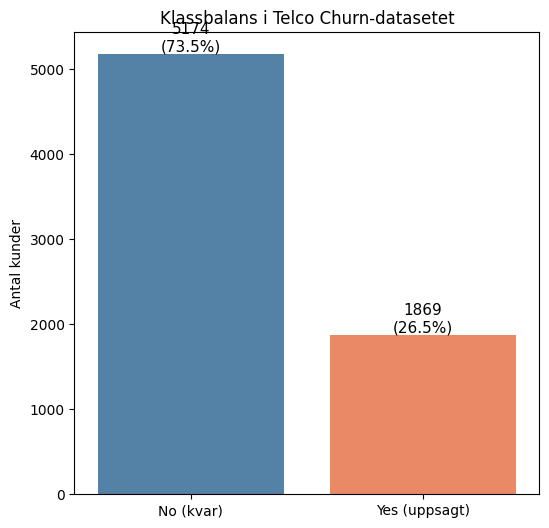

In [15]:
# Gör en countplot för att se obalans i datat

plt.figure(figsize=(6, 6))
ax = sns.countplot(x='Churn', data=df, palette=['steelblue', 'coral'])

# Sätt tydliga etiketter (0/1 är inte lika läsbart som No/Yes)
ax.set_xticklabels(['No (kvar)', 'Yes (uppsagt)'])
ax.set_xlabel('')
ax.set_ylabel('Antal kunder')
ax.set_title('Klassbalans i Telco Churn-datasetet')

# Lägg på antal + procent ovanför staplarna
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f'{count}\n({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.show()

In [16]:
# Skalning
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("Efter skalning (train):")
print(X_train_scaled[numeric_cols].describe().round(2))

Efter skalning (train):
        tenure  MonthlyCharges  TotalCharges  SeniorCitizen
count  4930.00         4930.00       4930.00        4930.00
mean      0.00            0.00         -0.00          -0.00
std       1.00            1.00          1.00           1.00
min      -1.32           -1.54         -1.00          -0.44
25%      -0.95           -0.97         -0.83          -0.44
50%      -0.14            0.19         -0.40          -0.44
75%       0.95            0.83          0.68          -0.44
max       1.60            1.78          2.78           2.28


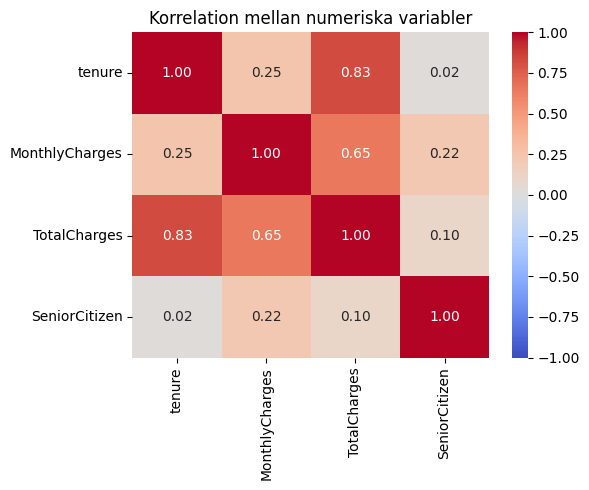

                tenure  MonthlyCharges  TotalCharges  SeniorCitizen
tenure            1.00            0.25          0.83           0.02
MonthlyCharges    0.25            1.00          0.65           0.22
TotalCharges      0.83            0.65          1.00           0.10
SeniorCitizen     0.02            0.22          0.10           1.00


In [17]:
# A: Numeriska mot varandra (multikollinearitet)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr_num = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.2f')
plt.title('Korrelation mellan numeriska variabler')
plt.tight_layout()
plt.show()

print(corr_num.round(2))


# Vi ser att TotalCharges korrelerar ofantligt högt med hur länge man har varit kund, vilket är naturligt. 
# Här har vi multikollinearitet som vi eventuellt bör hantera genom att droppa TotalCharges.

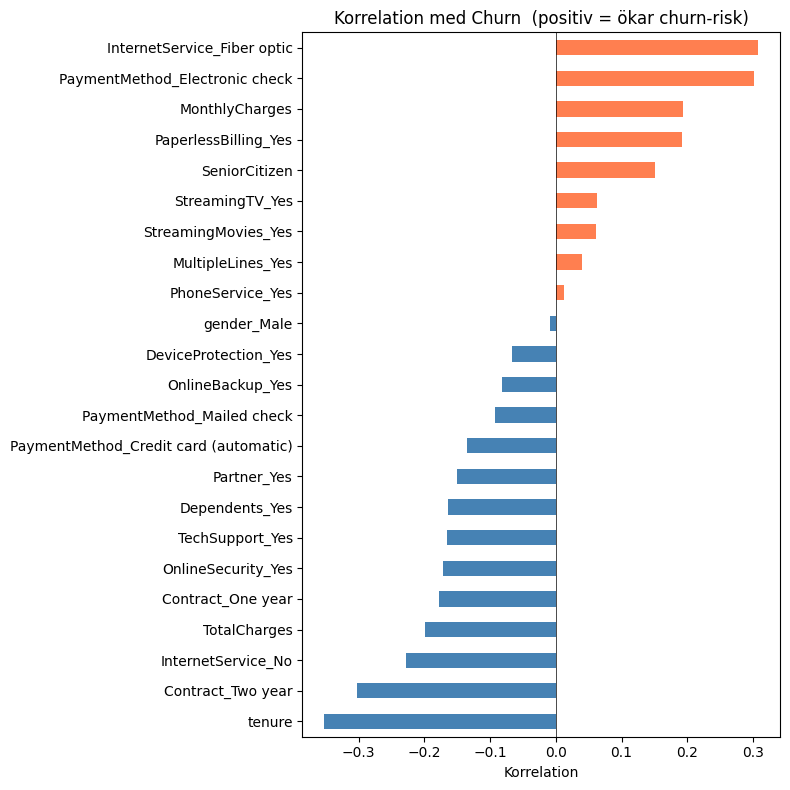

tenure                                  -0.352
Contract_Two year                       -0.302
InternetService_No                      -0.228
TotalCharges                            -0.198
Contract_One year                       -0.178
OnlineSecurity_Yes                      -0.171
TechSupport_Yes                         -0.165
Dependents_Yes                          -0.164
Partner_Yes                             -0.150
PaymentMethod_Credit card (automatic)   -0.134
PaymentMethod_Mailed check              -0.092
OnlineBackup_Yes                        -0.082
DeviceProtection_Yes                    -0.066
gender_Male                             -0.009
PhoneService_Yes                         0.012
MultipleLines_Yes                        0.040
StreamingMovies_Yes                      0.061
StreamingTV_Yes                          0.063
SeniorCitizen                            0.151
PaperlessBilling_Yes                     0.192
MonthlyCharges                           0.193
PaymentMethod

In [18]:
# B: Allt mot Churn (vad driver churn?)
df_corr = X.copy()
df_corr['Churn'] = y
churn_corr = df_corr.corr()['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(8, 8))
colors = ['steelblue' if v < 0 else 'coral' for v in churn_corr]
churn_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Korrelation med Churn  (positiv = ökar churn-risk)')
plt.xlabel('Korrelation')
plt.tight_layout()
plt.show()

print(churn_corr.round(3))

In [19]:
#  Mycket intressant! Fiberkunder verkar leda ligan i uppsagda kontrakt.  De som betalar med elektronisk check och de med hög månadskostnad har en tendens att säga upp kontraktet! Intressant.
# De som har varit kunder länge har en tendens att fortsätta vara kunder.

In [20]:
# Logistisk regression med statsmodels

import statsmodels.api as sm

# Lägg till intercept manuellt (säkrare än sm.add_constant)
X_train_sm = X_train_scaled.copy()
X_train_sm.insert(0, 'const', 1.0)

# Fitta logistisk regression
model = sm.Logit(y_train, X_train_sm)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.412899
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 4930
Model:                          Logit   Df Residuals:                     4906
Method:                           MLE   Df Model:                           23
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.2863
Time:                        09:13:07   Log-Likelihood:                -2035.6
converged:                       True   LL-Null:                       -2852.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -3.9380      

In [21]:
# Modellen som helhet är statistisk signifikant och Pseudo R-square på 0,29 kan anses som helt OK! Antal observationer 4930 vilket är hela träningssetet.

Confusion Matrix:
[[1395  157]
 [ 248  313]]

              precision    recall  f1-score   support

    Kvar (0)       0.85      0.90      0.87      1552
   Churn (1)       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



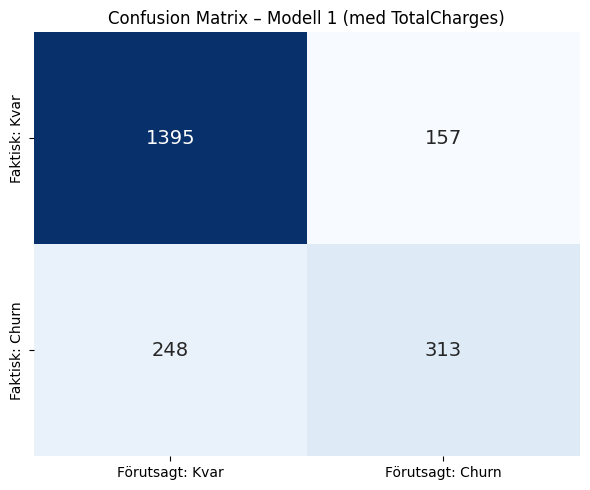

In [22]:
# Predicera på testdata
X_test_sm = X_test_scaled.copy()
X_test_sm.insert(0, 'const', 1.0)

y_pred_proba = result.predict(X_test_sm)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test, y_pred, target_names=['Kvar (0)', 'Churn (1)']))

# Visualisera
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Förutsagt: Kvar', 'Förutsagt: Churn'],
            yticklabels=['Faktisk: Kvar', 'Faktisk: Churn'],
            cbar=False, ax=ax, annot_kws={'size': 14})
ax.set_title('Confusion Matrix – Modell 1 (med TotalCharges)')
plt.tight_layout()
plt.show()

C:\Users\ES7233\AppData\Local\Temp\ipykernel_2520\3038308230.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Churn', y='TotalCharges', ax=axes[0],
C:\Users\ES7233\AppData\Local\Temp\ipykernel_2520\3038308230.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Kvar', 'Churn'])


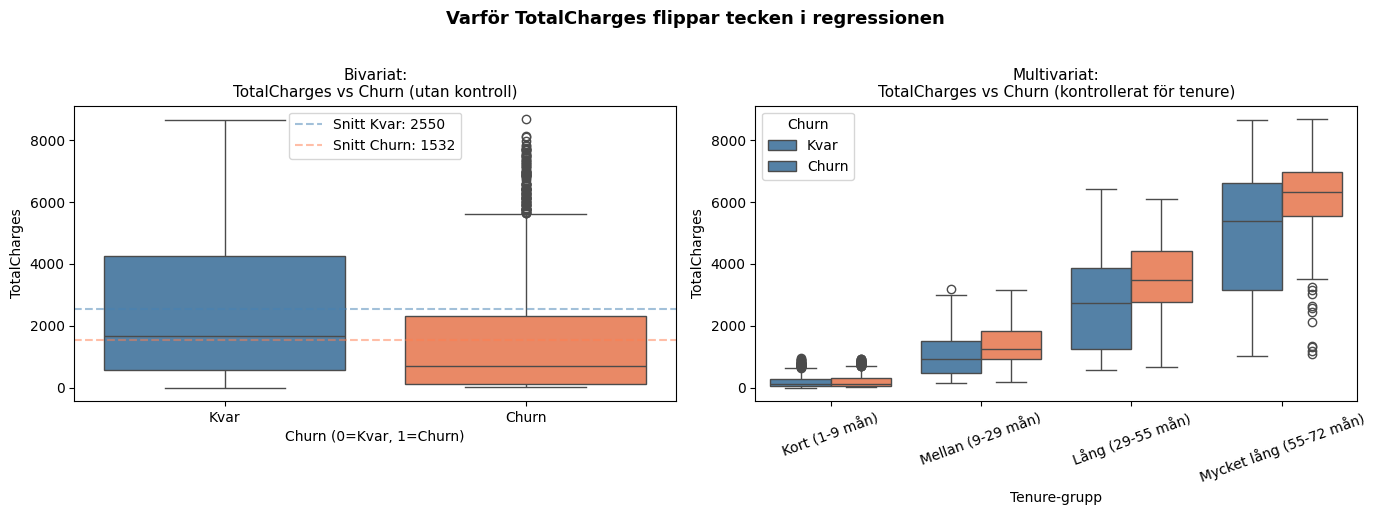

In [23]:
# Skapa fyra kvartiler av tenure för att kunna gruppera
df_viz = df.copy()
df_viz['tenure_grupp'] = pd.qcut(df_viz['tenure'].clip(lower=1),
                                  q=4,
                                  labels=['Kort (1-9 mån)',
                                          'Mellan (9-29 mån)',
                                          'Lång (29-55 mån)',
                                          'Mycket lång (55-72 mån)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Plot 1: Bivariat ===
sns.boxplot(data=df_viz, x='Churn', y='TotalCharges', ax=axes[0],
            palette=['steelblue', 'coral'])
axes[0].set_title('Bivariat:\nTotalCharges vs Churn (utan kontroll)',
                  fontsize=11)
axes[0].set_xlabel('Churn (0=Kvar, 1=Churn)')
axes[0].set_xticklabels(['Kvar', 'Churn'])

# Beräkna och visa medelvärden
means = df_viz.groupby('Churn')['TotalCharges'].mean()
axes[0].axhline(means[0], color='steelblue', linestyle='--', alpha=0.5,
                label=f'Snitt Kvar: {means[0]:.0f}')
axes[0].axhline(means[1], color='coral', linestyle='--', alpha=0.5,
                label=f'Snitt Churn: {means[1]:.0f}')
axes[0].legend()

# === Plot 2: Multivariat – inom samma tenure-grupp ===
sns.boxplot(data=df_viz, x='tenure_grupp', y='TotalCharges',
            hue='Churn', ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('Multivariat:\nTotalCharges vs Churn (kontrollerat för tenure)',
                  fontsize=11)
axes[1].set_xlabel('Tenure-grupp')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Churn', labels=['Kvar', 'Churn'])

plt.suptitle('Varför TotalCharges flippar tecken i regressionen',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Korrelationen mellan TotalCharges och Churn har varit en illusion, det är tenure som varit drivande, dvs hur länge man varit kund.
# Med det så beslutar vi oss för att droppa TotalCHarges-variableln.

In [25]:
# Vi sparar metrikerna från denna modell och efter det gör vi om testet med TotalCharges droppat!

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

resultat = {
    'Modell 1 (med TotalCharges, tröskel 0.5)': {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_proba),
    }
}

print(pd.DataFrame(resultat).round(3))

           Modell 1 (med TotalCharges, tröskel 0.5)
Accuracy                                      0.808
Precision                                     0.666
Recall                                        0.558
F1                                            0.607
ROC-AUC                                       0.845


In [26]:
# Logistisk regression igen men droppa TotalCharges

# Lägg till intercept manuellt (säkrare än sm.add_constant)
X_train_sm2 = X_train_scaled.copy()
X_train_sm2 = X_train_sm2.drop(columns=['TotalCharges'])
X_train_sm2.insert(0, 'const', 1.0)

# Fitta logistisk regression
model2 = sm.Logit(y_train, X_train_sm2)
result2 = model2.fit()

print(result2.summary())


Optimization terminated successfully.
         Current function value: 0.414384
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 4930
Model:                          Logit   Df Residuals:                     4907
Method:                           MLE   Df Model:                           22
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.2837
Time:                        09:13:08   Log-Likelihood:                -2042.9
converged:                       True   LL-Null:                       -2852.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -3.9877      

Modell 2 – Confusion Matrix:
[[1387  165]
 [ 257  304]]

              precision    recall  f1-score   support

    Kvar (0)       0.84      0.89      0.87      1552
   Churn (1)       0.65      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.75      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



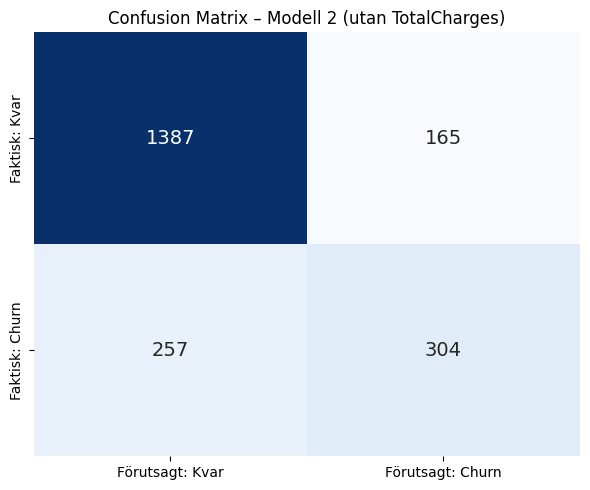


Jämförelse:
           Modell 1 (med TotalCharges, tröskel 0.5)  \
Accuracy                                      0.808   
Precision                                     0.666   
Recall                                        0.558   
F1                                            0.607   
ROC-AUC                                       0.845   

           Modell 2 (utan TotalCharges, tröskel 0.5)  \
Accuracy                                       0.800   
Precision                                      0.648   
Recall                                         0.542   
F1                                             0.590   
ROC-AUC                                        0.842   

           Modell 1 (Youden tröskel ≈ 0.25)  \
Accuracy                              0.736   
Precision                             0.502   
Recall                                0.824   
F1                                    0.624   
ROC-AUC                               0.845   

           KNN ej optimerad (k=5, tr

In [71]:
# Ny confusion matrix

# Modell 2-prediktion
X_test_sm2 = X_test_scaled.copy()
X_test_sm2 = X_test_sm2.drop(columns=['TotalCharges'])
X_test_sm2.insert(0, 'const', 1.0)

y_pred_proba2 = result2.predict(X_test_sm2)
y_pred2 = (y_pred_proba2 >= 0.5).astype(int)

# Confusion matrix
cm2 = confusion_matrix(y_test, y_pred2)
print("Modell 2 – Confusion Matrix:")
print(cm2)
print()
print(classification_report(y_test, y_pred2, target_names=['Kvar (0)', 'Churn (1)']))

# Visualisera
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Förutsagt: Kvar', 'Förutsagt: Churn'],
            yticklabels=['Faktisk: Kvar', 'Faktisk: Churn'],
            cbar=False, ax=ax, annot_kws={'size': 14})
ax.set_title('Confusion Matrix – Modell 2 (utan TotalCharges)')
plt.tight_layout()
plt.show()

# Spara resultat för jämförelse
resultat['Modell 2 (utan TotalCharges, tröskel 0.5)'] = {
    'Accuracy':  accuracy_score(y_test, y_pred2),
    'Precision': precision_score(y_test, y_pred2),
    'Recall':    recall_score(y_test, y_pred2),
    'F1':        f1_score(y_test, y_pred2),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba2),
}

print("\nJämförelse:")
print(pd.DataFrame(resultat).round(3))

In [28]:
# Inget blev bättre med droppad TotalCharges!
# Här verkar vi ha en klassiskt konflikt mellan ML och statistiklära. 
# Statistisk modellering: "Modellen ska berätta något om verkligheten. Tolkningsbara koefficienter är viktigare."
# ML: "Modellen ska prediktera bra. Punkt. Tolkning är sekundärt."
# Då detta är en kurs i ML bestämmer vi oss för att fortsätta med TotalCharges inkluderat

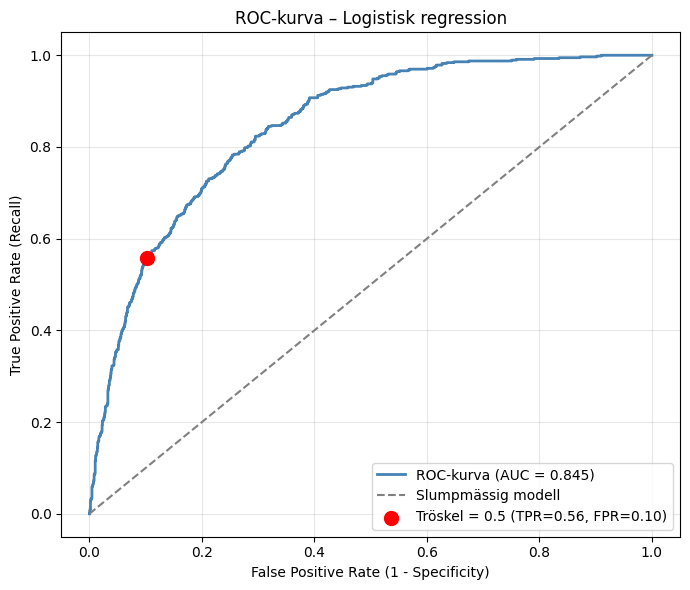

In [29]:
# Vi provar att tröskeloptimera för att se om vi kan förbättra prestandan!

from sklearn.metrics import roc_curve, roc_auc_score

# Räkna ut ROC-kurvan
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plotta
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC-kurva (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Slumpmässig modell')

# Markera tröskel 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[idx_05], tpr[idx_05], color='red', s=100, zorder=5,
            label=f'Tröskel = 0.5 (TPR={tpr[idx_05]:.2f}, FPR={fpr[idx_05]:.2f})')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-kurva – Logistisk regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Optimal tröskel (Youden's J): 0.246
Vid den tröskeln: TPR = 0.824, FPR = 0.295
Youden's J vid 0.5:    0.456
Youden's J vid optimal: 0.528

Confusion Matrix vid tröskel = 0.246:
[[1094  458]
 [  99  462]]

              precision    recall  f1-score   support

    Kvar (0)       0.92      0.70      0.80      1552
   Churn (1)       0.50      0.82      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.81      0.74      0.75      2113



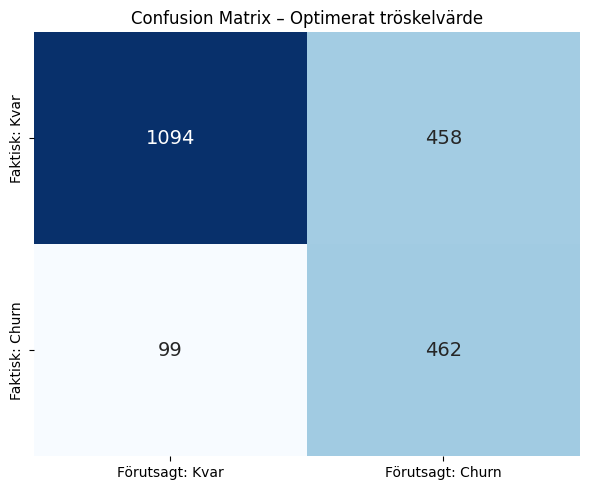


Jämförelse:
           Modell 1 (med TotalCharges, tröskel 0.5)  \
Accuracy                                      0.808   
Precision                                     0.666   
Recall                                        0.558   
F1                                            0.607   
ROC-AUC                                       0.845   

           Modell 2 (utan TotalCharges, tröskel 0.5)  \
Accuracy                                       0.800   
Precision                                      0.648   
Recall                                         0.542   
F1                                             0.590   
ROC-AUC                                        0.842   

           Modell 1 (Youden tröskel ≈ 0.25)  \
Accuracy                              0.736   
Precision                             0.502   
Recall                                0.824   
F1                                    0.624   
ROC-AUC                               0.845   

           KNN ej optimerad (k=5, tr

In [73]:
# Ny confusion matrix vid den optimala tröskeln

# Youden's J = TPR - FPR (samma som sensitivitet + specificitet - 1)
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal tröskel (Youden's J): {optimal_threshold:.3f}")
print(f"Vid den tröskeln: TPR = {tpr[optimal_idx]:.3f}, FPR = {fpr[optimal_idx]:.3f}")
print(f"Youden's J vid 0.5:    {J[idx_05]:.3f}")
print(f"Youden's J vid optimal: {J[optimal_idx]:.3f}")

# Predicera om med den nya tröskeln
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_optimal)
print(f"\nConfusion Matrix vid tröskel = {optimal_threshold:.3f}:")
print(cm_opt)
print()
print(classification_report(y_test, y_pred_optimal, target_names=['Kvar (0)', 'Churn (1)']))

# Visualisera
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Förutsagt: Kvar', 'Förutsagt: Churn'],
            yticklabels=['Faktisk: Kvar', 'Faktisk: Churn'],
            cbar=False, ax=ax, annot_kws={'size': 14})
ax.set_title('Confusion Matrix – Optimerat tröskelvärde')
plt.tight_layout()
plt.show()

# Lägg till i jämförelsen
resultat[f'Modell 1 (Youden tröskel ≈ {optimal_threshold:.2f})'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_optimal),
    'Precision': precision_score(y_test, y_pred_optimal),
    'Recall':    recall_score(y_test, y_pred_optimal),
    'F1':        f1_score(y_test, y_pred_optimal),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba),
}

print("\nJämförelse:")
print(pd.DataFrame(resultat).round(3))

In [31]:
# Confusion matrix modell 1:
# Confusion Matrix:
# [[1395  157]
# [ 248  313]]
# Med den optimala tröskeln enligt Youden's J så identifierar vi 149 fler kunder som riskerar att säga upp sig, 
# dock med en kostnad att vi felaktigt förutser att 301 fler kunder ska lämna oss som egentligen hade stannat! (Trade off)

In [32]:
# Logistisk regression END



# KNN START

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Fitta med default k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Prediktera
y_pred_knn = knn.predict(X_test_scaled)
y_pred_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]  # sannolikhet för klass 1

# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(f"KNN (k=5) – Confusion Matrix:")
print(cm_knn)
print()
print(classification_report(y_test, y_pred_knn, target_names=['Kvar (0)', 'Churn (1)']))

resultat['KNN ej optimerad (k=5, tröskel 0.5)'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall':    recall_score(y_test, y_pred_knn),
    'F1':        f1_score(y_test, y_pred_knn),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba_knn),
}

KNN (k=5) – Confusion Matrix:
[[1309  243]
 [ 257  304]]

              precision    recall  f1-score   support

    Kvar (0)       0.84      0.84      0.84      1552
   Churn (1)       0.56      0.54      0.55       561

    accuracy                           0.76      2113
   macro avg       0.70      0.69      0.69      2113
weighted avg       0.76      0.76      0.76      2113



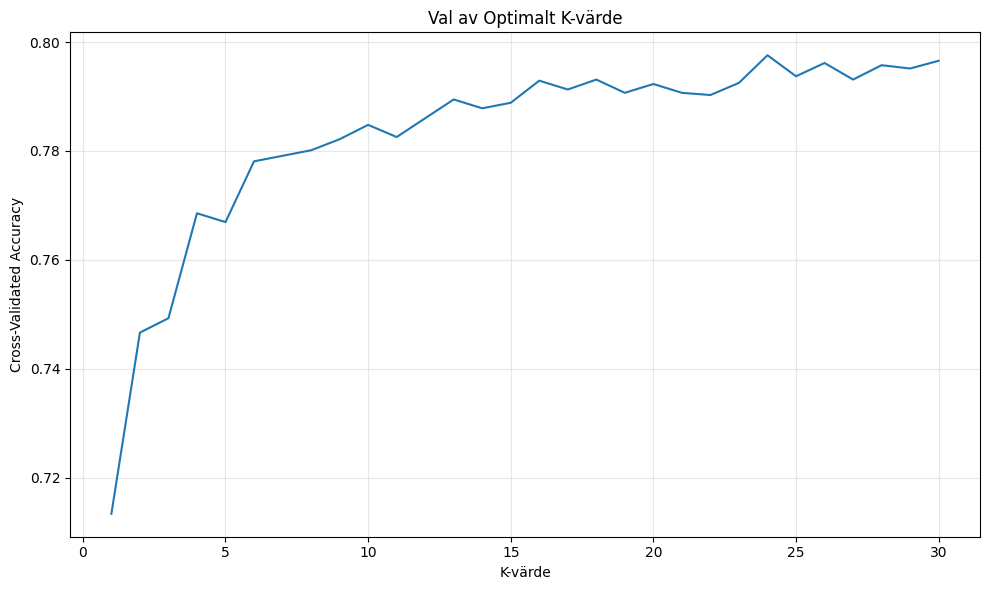

In [34]:
# Som väntat är resultatet sämre än vid den logistiska regressionen, men vi har inte optimerat k-värdet än! Vi anvönder en plot för att hitta det optimala värdet.

from sklearn.model_selection import cross_val_score

# Testa olika k-värden och se hur det påverkar modellens prestanda
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# Plotta resultaten
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores)
plt.xlabel('K-värde')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Val av Optimalt K-värde')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Runt 20 verkar vi ha en platpå där det inte händer så mycket mer. Provar att köra om med det!

knn2 = KNeighborsClassifier(n_neighbors=20)
knn2.fit(X_train_scaled, y_train)

y_pred_knn_best = knn2.predict(X_test_scaled)
y_pred_proba_knn_best = knn2.predict_proba(X_test_scaled)[:, 1]

cm_knn2 = confusion_matrix(y_test, y_pred_knn_best)      # ✓ knn_best
print(f"KNN (k=20) – Confusion Matrix:")
print(cm_knn2)
print()
print(classification_report(y_test, y_pred_knn_best,     # ✓ knn_best
                            target_names=['Kvar (0)', 'Churn (1)']))

resultat['KNN (k=20, tröskel 0.5)'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_knn_best),
    'Precision': precision_score(y_test, y_pred_knn_best),
    'Recall':    recall_score(y_test, y_pred_knn_best),
    'F1':        f1_score(y_test, y_pred_knn_best),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba_knn_best),
}

KNN (k=20) – Confusion Matrix:
[[1376  176]
 [ 253  308]]

              precision    recall  f1-score   support

    Kvar (0)       0.84      0.89      0.87      1552
   Churn (1)       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [36]:
# Att jämföra med vår logistiska regression
df_resultat = pd.DataFrame(resultat).T.round(3)
print(pd.DataFrame(resultat).round(3))

           Modell 1 (med TotalCharges, tröskel 0.5)  \
Accuracy                                      0.808   
Precision                                     0.666   
Recall                                        0.558   
F1                                            0.607   
ROC-AUC                                       0.845   

           Modell 2 (utan TotalCharges, tröskel 0.5)  \
Accuracy                                       0.800   
Precision                                      0.648   
Recall                                         0.542   
F1                                             0.590   
ROC-AUC                                        0.842   

           Modell 1 (Youden tröskel ≈ 0.25)  \
Accuracy                              0.736   
Precision                             0.502   
Recall                                0.824   
F1                                    0.624   
ROC-AUC                               0.845   

           KNN ej optimerad (k=5, tröskel 0.5)  K

In [37]:
# KNN med optimal tröskel, Youden's J.

fpr_knn, tpr_knn, thresh_knn = roc_curve(y_test, y_pred_proba_knn_best)
J_knn = tpr_knn - fpr_knn
optimal_idx_knn = np.argmax(J_knn)
optimal_threshold_knn = thresh_knn[optimal_idx_knn]

y_pred_knn_opt = (y_pred_proba_knn_best >= optimal_threshold_knn).astype(int)

print(f"KNN optimal tröskel: {optimal_threshold_knn:.3f}")
print(confusion_matrix(y_test, y_pred_knn_opt))
print(classification_report(y_test, y_pred_knn_opt,
                            target_names=['Kvar', 'Churn']))

resultat[f'KNN (k=20, Youden ≈ {optimal_threshold_knn:.2f})'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_knn_opt),
    'Precision': precision_score(y_test, y_pred_knn_opt),
    'Recall':    recall_score(y_test, y_pred_knn_opt),
    'F1':        f1_score(y_test, y_pred_knn_opt),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba_knn_best),
}
print("\nSlutlig jämförelse:")
print(pd.DataFrame(resultat).T.round(3))

KNN optimal tröskel: 0.300
[[1043  509]
 [  99  462]]
              precision    recall  f1-score   support

        Kvar       0.91      0.67      0.77      1552
       Churn       0.48      0.82      0.60       561

    accuracy                           0.71      2113
   macro avg       0.69      0.75      0.69      2113
weighted avg       0.80      0.71      0.73      2113


Slutlig jämförelse:
                                           Accuracy  Precision  Recall     F1  \
Modell 1 (med TotalCharges, tröskel 0.5)      0.808      0.666   0.558  0.607   
Modell 2 (utan TotalCharges, tröskel 0.5)     0.800      0.648   0.542  0.590   
Modell 1 (Youden tröskel ≈ 0.25)              0.736      0.502   0.824  0.624   
KNN ej optimerad (k=5, tröskel 0.5)           0.763      0.556   0.542  0.549   
KNN (k=20, tröskel 0.5)                       0.797      0.636   0.549  0.589   
KNN (k=20, Youden ≈ 0.30)                     0.712      0.476   0.824  0.603   

                              

In [38]:
# Vinnare är logistsk regression på alla kategorier! 

In [39]:
# KNN END

# Survival analysis start!

In [40]:
# Hur många kunder har tenure = 0?
print(f"Kunder med tenure=0: {(df['tenure'] == 0).sum()}") # Helt nya kunder
print(f"Av dessa har churn=1: {((df['tenure'] == 0) & (df['Churn'] == 1)).sum()}") # Helt nya kunder som har avslutat

# Lifelines klarar inte tid = 0, vilket vi behöver åtgärda

Kunder med tenure=0: 11
Av dessa har churn=1: 0


In [41]:
# 11 rader i sammanhanget är försumbart, så vi kan filtrera bort dom

# Skapa survival-dataset
df_surv = df[df['tenure'] > 0].copy()
print(f"Survival dataset: {df_surv.shape}")  # ska vara (7032, 21)



Survival dataset: (7032, 21)


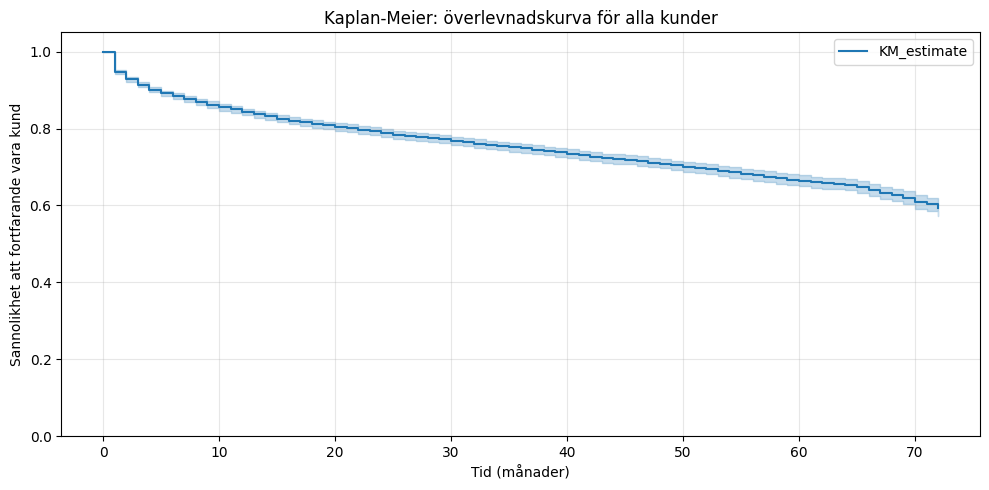


Median survival time: inf
Sannolikhet att vara kvar efter 12 mån: 0.843
Sannolikhet att vara kvar efter 24 mån: 0.789
Sannolikhet att vara kvar efter 60 mån: 0.664


In [42]:
# Kaplan-Meier-kurvan
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations=df_surv['tenure'], event_observed=df_surv['Churn'])

# Plotta
fig, ax = plt.subplots(figsize=(10, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel('Tid (månader)')
ax.set_ylabel('Sannolikhet att fortfarande vara kund')
ax.set_title('Kaplan-Meier: överlevnadskurva för alla kunder')
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Skriv ut nyckelvärden
print(f"\nMedian survival time: {kmf.median_survival_time_}")
print(f"Sannolikhet att vara kvar efter 12 mån: {kmf.predict(12):.3f}")
print(f"Sannolikhet att vara kvar efter 24 mån: {kmf.predict(24):.3f}")
print(f"Sannolikhet att vara kvar efter 60 mån: {kmf.predict(60):.3f}")

In [43]:
# Merparten av kunderna tenderar att vara kvar under studietidens längd. 66,4%! Av 100 kunder är 66 kvar. 
# Kurvan faller snabbt i början, vilket kan vara kunder som ångrar sig.
# När kurvan planat ut tenderar kunderna att stanna i högre grad! Var fjärde kund slutar ändå som kund, så det kanske kan anses som högt.
# inf ennbär att mer än hälften är kvar efter studietidens slut!

In [44]:
# log-rank för att se resultatet statistiskt

from lifelines.statistics import multivariate_logrank_test

# Multivariate log-rank för 3 grupper samtidigt
results = multivariate_logrank_test(
    df_surv['tenure'],
    df_surv['Contract'],
    df_surv['Churn']
)
print(results.summary)
print(f"\np-värde: {results.p_value}")
print(f"Test-statistic: {results.test_statistic:.2f}")

   test_statistic    p  -log2(p)
0     2352.872538  0.0       inf

p-värde: 0.0
Test-statistic: 2352.87


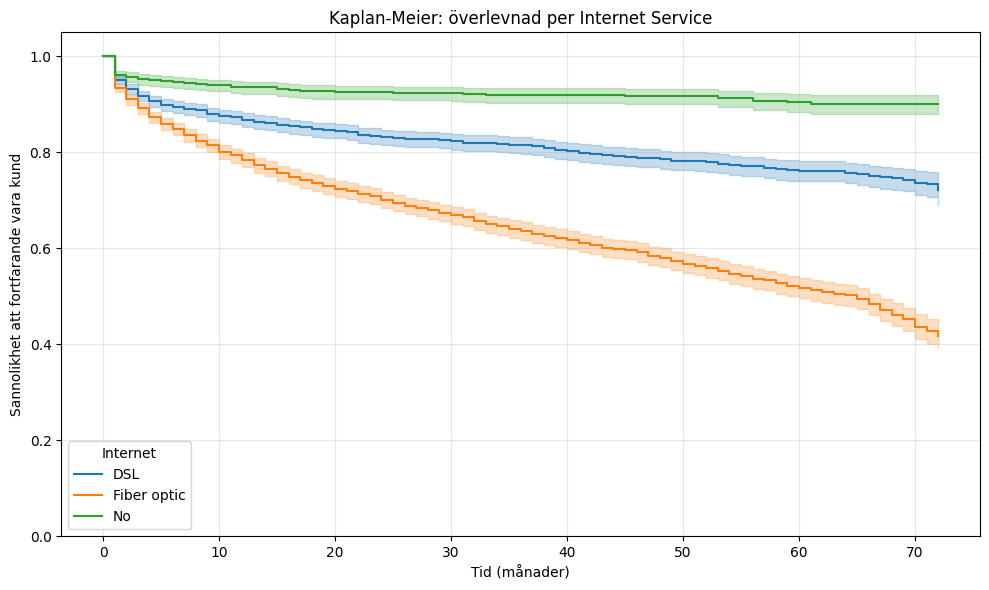


p-värde: 0.000000
Test-statistic: 520.12


In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

for service_type in df_surv['InternetService'].unique():
    mask = df_surv['InternetService'] == service_type
    
    kmf = KaplanMeierFitter()
    kmf.fit(durations=df_surv.loc[mask, 'tenure'],
            event_observed=df_surv.loc[mask, 'Churn'],
            label=service_type)
    kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel('Tid (månader)')
ax.set_ylabel('Sannolikhet att fortfarande vara kund')
ax.set_title('Kaplan-Meier: överlevnad per Internet Service')
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)
ax.legend(title='Internet', loc='lower left')
plt.tight_layout()
plt.show()

# Log-rank
from lifelines.statistics import multivariate_logrank_test
results = multivariate_logrank_test(
    df_surv['tenure'],
    df_surv['InternetService'],
    df_surv['Churn']
)
print(f"\np-värde: {results.p_value:f}")
print(f"Test-statistic: {results.test_statistic:.2f}")

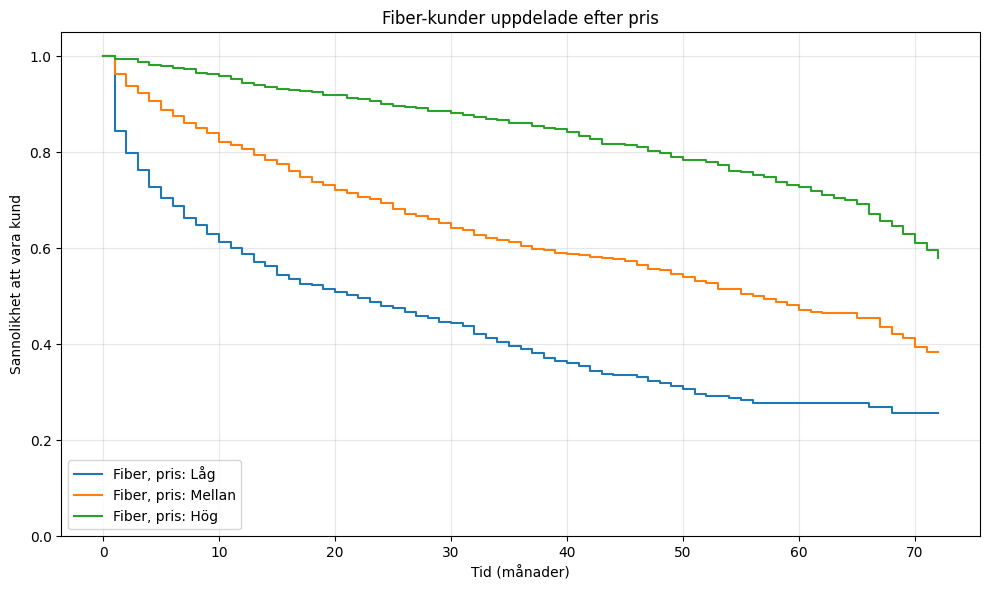

In [46]:
# Kunder med fiberoptik tenderar avsluta sina abonemang i högre grad än övriga! Är dessa kunder missnöjda med servicen i högre grad?

# Vi kan dela fiber-kunder i prisgrupper och se om effekten kvarstår!

# Dela fiberkunder i prisgrupper
fiber = df_surv[df_surv['InternetService'] == 'Fiber optic'].copy()
fiber['pris_grupp'] = pd.qcut(fiber['MonthlyCharges'], q=3,
                                labels=['Låg', 'Mellan', 'Hög'])

# Plotta KM per prisgrupp inom fiber
fig, ax = plt.subplots(figsize=(10, 6))
for grupp in ['Låg', 'Mellan', 'Hög']:
    mask = fiber['pris_grupp'] == grupp
    kmf = KaplanMeierFitter()
    kmf.fit(durations=fiber.loc[mask, 'tenure'],
            event_observed=fiber.loc[mask, 'Churn'],
            label=f'Fiber, pris: {grupp}')
    kmf.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel('Tid (månader)')
ax.set_ylabel('Sannolikhet att vara kund')
ax.set_title('Fiber-kunder uppdelade efter pris')
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [47]:
# Wow inte vad vi förväntade oss! De med högt pris tenderar att stanna längre en de med lågt pris! 
# Teori: De med hög MonthlyCharges har flera tilläggstjänster och det kan påverka tendensen till att stanna! Ju fler tjänster man har desto mindre chans att man lämnar

In [48]:
# COX

from lifelines import CoxPHFitter

# Bygg dataset för Cox
df_cox = df_surv.copy()

# Droppa kolumner vi inte behöver
df_cox = df_cox.drop(columns=['customerID'])

# Konvertera Churn till int (0/1) om det inte redan är det
if df_cox['Churn'].dtype != 'int64':
    df_cox['Churn'] = df_cox['Churn'].map({'No': 0, 'Yes': 1}).fillna(df_cox['Churn'])

# Dummy-koda kategoriska variabler (samma som tidigare)
df_cox = pd.get_dummies(df_cox, drop_first=True, dtype=int)

print(f"Cox-dataset shape: {df_cox.shape}")
print(f"Kolumner: {df_cox.columns.tolist()}")

Cox-dataset shape: (7032, 24)
Kolumner: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [49]:
# Droppa TotalCharges (multikollinearitet med tenure)
# tenure ska kvar – det blir vår tidsvariabel
df_cox = df_cox.drop(columns=['TotalCharges'])

print(f"Cox-dataset efter drop: {df_cox.shape}")

Cox-dataset efter drop: (7032, 23)


In [50]:
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='tenure', event_col='Churn')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 7032
number of events observed = 1869
   partial log-likelihood = -13884.60
         time fit was run = 2026-05-07 07:13:14 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
SeniorCitizen                         -0.07      0.93      0.06           -0.18            0.04                0.83                1.04
MonthlyCharges                        -0.01      0.99      0.02           -0.05            0.04                0.95                1.04
gender_Male                           -0.09      0.92      0.05           -0.18            0.01                0.84                1.01
Partner_Yes                           -0.52      0.60      0.06           -0.63           -0.41                0.53                0.66
Dependents_Yes                        -0.05      0.95      0.07           -0.19            0.08                0.83                1.08
PhoneService_Yes                       0.25      1.29      0.47           -0.67            1.18                0.51                3.25
MultipleLines_Yes                     -0.42      0.66      0.13           -0.67           -0.17                0.51                0.84
InternetService_Fiber optic            0.59      1.80      0.58           -0.54            1.71                0.58                5.55
InternetService_No                    -1.30      0.27      0.59           -2.45           -0.15                0.09                0.86
OnlineSecurity_Yes                    -0.61      0.54      0.13           -0.87           -0.35                0.42                0.70
OnlineBackup_Yes                      -0.61      0.54      0.13           -0.86           -0.36                0.42                0.69
DeviceProtection_Yes                  -0.28      0.75      0.13           -0.53           -0.04                0.59                0.96
TechSupport_Yes                       -0.37      0.69      0.13           -0.63           -0.11                0.53                0.90
StreamingTV_Yes                        0.04      1.04      0.24           -0.42            0.50                0.66                1.66
StreamingMovies_Yes                   -0.05      0.95      0.24           -0.52            0.41                0.60                1.50
Contract_One year                     -1.62      0.20      0.09           -1.79           -1.44                0.17                0.24
Contract_Two year                     -3.23      0.04      0.16           -3.56           -2.91                0.03                0.05
PaperlessBilling_Yes                   0.18      1.20      0.06            0.07            0.29                1.07                1.34
PaymentMethod_Credit card (automatic) -0.08      0.92      0.09           -0.26            0.09                0.77                1.10
PaymentMethod_Electronic check         0.59      1.80      0.07            0.45            0.73                1.56                2.07
PaymentMethod_Mailed check             0.57      1.76      0.09            0.39            0.74                1.48                2.09

                                       cmp to      z      p  -log2(p)
covariate                                                            
SeniorCitizen                            0.00  -1.26   0.21      2.27
MonthlyCharges                           0.00  -0.35   0.73      0.46
gender_Male                              0.00  -1.84   0.07      3.93
Partner_Yes                              0.00  -9.40 <0.005     67.30
Dependents_Yes                           0.00  -0.78   0.43      1.20
PhoneService_Yes

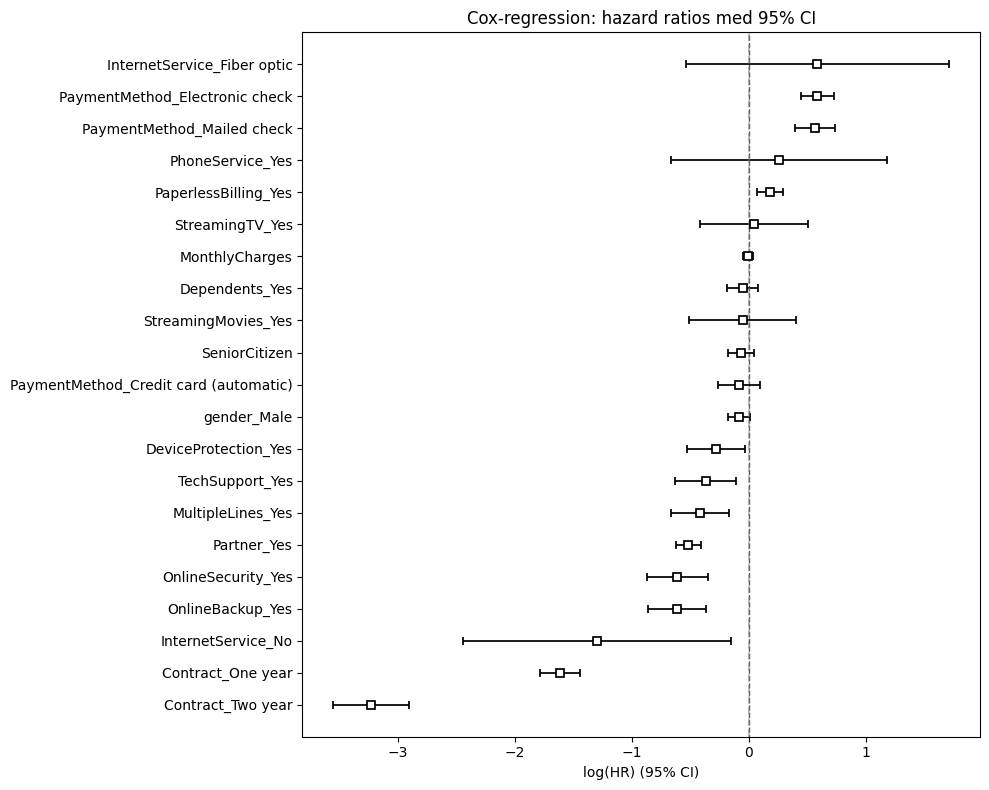

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))
cph.plot(ax=ax)
ax.set_title('Cox-regression: hazard ratios med 95% CI')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [52]:
"""
Concordance 0.87 betyder: om vi tar två slumpmässiga kunder (en som sa upp sig och en som stannade), kommer modellen rangordna dem rätt 87% av tiden. 
Det är högre än våra logistiska modellers ROC-AUC (0.845). 
Cox utnyttjar tids-informationen bättre än binär klassificering.

DOCK är InternetService_Fiber optic inte längre signifikant i cox, P-värde 0.31! 

Contract_Two year ger en massivt lägre risk för uppsägning en kund som har Month-to-month-kontrakt (referensvariabel).
En kund som är fastlåst i ett kontrakt har väl kanske inte ens möjlighet att churna, så det kanske inte betyder att kunden egentligen är lojal.

"""

'\nConcordance 0.87 betyder: om vi tar två slumpmässiga kunder (en som sa upp sig och en som stannade), kommer modellen rangordna dem rätt 87% av tiden. \nDet är högre än våra logistiska modellers ROC-AUC (0.845). \nCox utnyttjar tids-informationen bättre än binär klassificering.\n\nDOCK är InternetService_Fiber optic inte längre signifikant i cox, P-värde 0.31! \n\nContract_Two year ger en massivt lägre risk för uppsägning en kund som har Month-to-month-kontrakt (referensvariabel).\nEn kund som är fastlåst i ett kontrakt har väl kanske inte ens möjlighet att churna, så det kanske inte betyder att kunden egentligen är lojal.\n\n'

In [53]:
# Vi kan göra en Kaplan-Meier-plott för att undersöka vad som verkar ske efter månad 24 hos två-årskunderna.

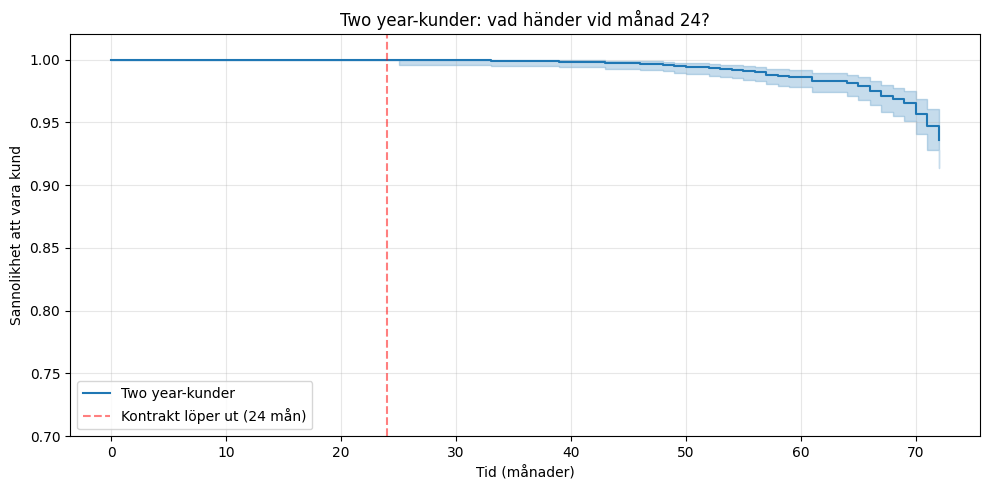

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))

twoyr = df_surv[df_surv['Contract'] == 'Two year']
kmf = KaplanMeierFitter()
kmf.fit(durations=twoyr['tenure'], event_observed=twoyr['Churn'],
        label='Two year-kunder')
kmf.plot_survival_function(ax=ax, ci_show=True)

# Markera 24-månadersmärket
ax.axvline(24, color='red', linestyle='--', alpha=0.5,
           label='Kontrakt löper ut (24 mån)')
ax.set_xlabel('Tid (månader)')
ax.set_ylabel('Sannolikhet att vara kund')
ax.set_title('Two year-kunder: vad händer vid månad 24?')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.7, 1.02)  # zooma in på toppen
plt.tight_layout()
plt.show()

In [55]:
# Det verkar som att man gladeligen förnyar kontraktet efter två-år. Vi verkar således ha en lojalitet bland kunderna också! Intressant!

In [56]:
# Proportional hazards-testet som är kritiskt
test_results = cph.check_assumptions(df_cox, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Partner_Yes' failed the non-proportional test: p-value is 0.0343.

   Advice: with so few unique values (only 2), you can include `strata=['Partner_Yes', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'MultipleLines_Yes' failed the non-proportional test: p-value is 0.0049.

   Advice: with so few unique values (only 2), you can include `strata=['MultipleLines_Yes', ...]`
in the call in `.fit`. See documentation in link [E] below.

3. Variable 'OnlineSecurity_Yes' failed the non-proportional test: p-value is 0.0052.

   Advice: with so few unique values (only 2), you can include `strata=['OnlineSecurity_Yes', ...]`
in the call in `.fit`. See documentation in link [E] below.

4. Variable 'OnlineBackup_Yes' failed the non-proportional test: p-value is 0.0306.

   Advice: with so few unique values (only 2), you can include `strata=['OnlineBackup_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

5. Variable 'DeviceProtect

In [57]:
# Många varningar!

In [58]:
# PCA + logistisk regression
# Logistisk regression gav oss ett bra utfall tidigare, så vi kan väl se om vi kan klämma ur lite mer genom att kombinera med PCA

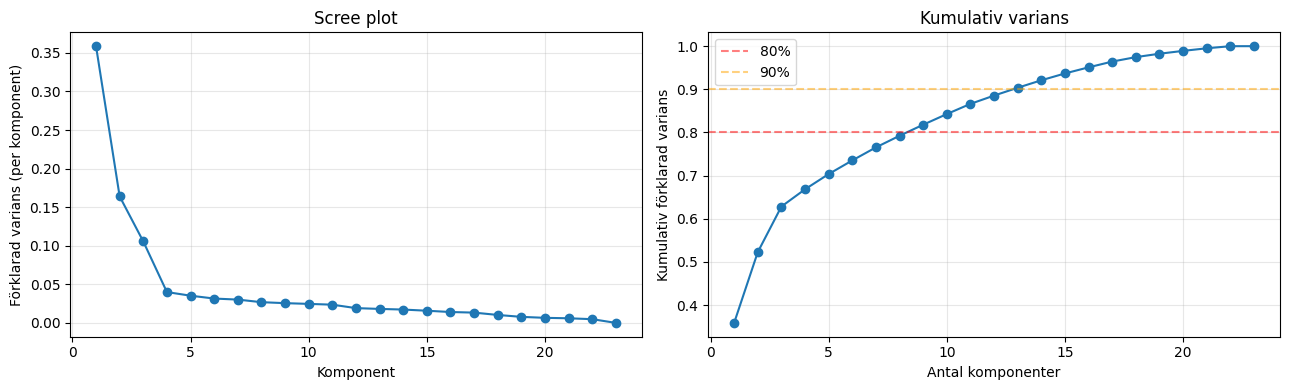

Antal komponenter för 80% varians: 9
Antal komponenter för 90% varians: 13


In [59]:
from sklearn.decomposition import PCA

# Fitta PCA på all dimensioner först för att se kurvan
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             pca_full.explained_variance_ratio_, marker='o')
axes[0].set_xlabel('Komponent')
axes[0].set_ylabel('Förklarad varians (per komponent)')
axes[0].set_title('Scree plot')
axes[0].grid(alpha=0.3)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker='o')
axes[1].axhline(0.80, color='red', linestyle='--', alpha=0.5, label='80%')
axes[1].axhline(0.90, color='orange', linestyle='--', alpha=0.5, label='90%')
axes[1].set_xlabel('Antal komponenter')
axes[1].set_ylabel('Kumulativ förklarad varians')
axes[1].set_title('Kumulativ varians')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Hitta antal komponenter för 80% och 90%
n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1
print(f"Antal komponenter för 80% varians: {n_80}")
print(f"Antal komponenter för 90% varians: {n_90}")

In [60]:
from sklearn.linear_model import LogisticRegression

n_components_list = [2, 5, 10, 12, 15, 18, 23]  # hela vägen från få till alla
resultat_pca = {}

for n in n_components_list:
    # PCA på training, transform test
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Logistisk regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_pca, y_train)
    
    y_pred_pca = lr.predict(X_test_pca)
    y_pred_proba_pca = lr.predict_proba(X_test_pca)[:, 1]
    
    # Spara
    resultat_pca[f'LR + PCA ({n} komp)'] = {
        'Accuracy':  accuracy_score(y_test, y_pred_pca),
        'Precision': precision_score(y_test, y_pred_pca),
        'Recall':    recall_score(y_test, y_pred_pca),
        'F1':        f1_score(y_test, y_pred_pca),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_proba_pca),
        'Förklarad varians': np.cumsum(pca.explained_variance_ratio_)[-1].round(3)
    }

print(pd.DataFrame(resultat_pca).T.round(3))

                    Accuracy  Precision  Recall     F1  ROC-AUC  \
LR + PCA (2 komp)      0.781      0.648   0.387  0.484    0.818   
LR + PCA (5 komp)      0.792      0.639   0.499  0.561    0.834   
LR + PCA (10 komp)     0.796      0.648   0.503  0.566    0.834   
LR + PCA (12 komp)     0.790      0.637   0.490  0.554    0.834   
LR + PCA (15 komp)     0.794      0.647   0.496  0.561    0.834   
LR + PCA (18 komp)     0.801      0.657   0.526  0.584    0.840   
LR + PCA (23 komp)     0.810      0.671   0.560  0.610    0.845   

                    Förklarad varians  
LR + PCA (2 komp)               0.523  
LR + PCA (5 komp)               0.704  
LR + PCA (10 komp)              0.843  
LR + PCA (12 komp)              0.885  
LR + PCA (15 komp)              0.937  
LR + PCA (18 komp)              0.975  
LR + PCA (23 komp)              1.000  


In [61]:
"""
"Att lägga PCA före logistisk regression hjälpte inte. 
Datan har 23 dimensioner – och alla bär verklig prediktiv signal. Logistisk regression hanterar redan höga dimensioner utmärkt utan dimensionsreduktion. 
PCA skulle vara mer värdefullt om vi hade hundratals dimensioner eller mycket brus.
"""

'\n"Att lägga PCA före logistisk regression hjälpte inte. \nDatan har 23 dimensioner – och alla bär verklig prediktiv signal. Logistisk regression hanterar redan höga dimensioner utmärkt utan dimensionsreduktion. \nPCA skulle vara mer värdefullt om vi hade hundratals dimensioner eller mycket brus.\n'

In [62]:
# PCA + KNN
# Kan vi få bättre utfall med KNN som är avståndsbaserad

In [63]:
n_components_list = [2, 5, 10, 12, 15, 18, 23]
resultat_knn_pca = {}

for n in n_components_list:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    knn_pca = KNeighborsClassifier(n_neighbors=20)
    knn_pca.fit(X_train_pca, y_train)
    
    y_pred_knn_pca = knn_pca.predict(X_test_pca)
    y_pred_proba_knn_pca = knn_pca.predict_proba(X_test_pca)[:, 1]
    
    resultat_knn_pca[f'KNN + PCA ({n} komp)'] = {
        'Accuracy':  accuracy_score(y_test, y_pred_knn_pca),
        'Precision': precision_score(y_test, y_pred_knn_pca),
        'Recall':    recall_score(y_test, y_pred_knn_pca),
        'F1':        f1_score(y_test, y_pred_knn_pca),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_proba_knn_pca),
        'Förklarad varians': np.cumsum(pca.explained_variance_ratio_)[-1].round(3)
    }

print(pd.DataFrame(resultat_knn_pca).T.round(3))

                     Accuracy  Precision  Recall     F1  ROC-AUC  \
KNN + PCA (2 komp)      0.779      0.618   0.444  0.517    0.814   
KNN + PCA (5 komp)      0.798      0.662   0.492  0.564    0.831   
KNN + PCA (10 komp)     0.796      0.646   0.508  0.569    0.829   
KNN + PCA (12 komp)     0.794      0.646   0.497  0.562    0.820   
KNN + PCA (15 komp)     0.796      0.641   0.522  0.576    0.824   
KNN + PCA (18 komp)     0.797      0.639   0.544  0.588    0.824   
KNN + PCA (23 komp)     0.797      0.636   0.549  0.589    0.825   

                     Förklarad varians  
KNN + PCA (2 komp)               0.523  
KNN + PCA (5 komp)               0.704  
KNN + PCA (10 komp)              0.843  
KNN + PCA (12 komp)              0.885  
KNN + PCA (15 komp)              0.937  
KNN + PCA (18 komp)              0.975  
KNN + PCA (23 komp)              1.000  


In [64]:
# Vinnaren verklar förbli Logistisk regression tillsammans med tröskeloptimering med Youden J.
# Där fick vi F1 0.624 och ROC-AUC 0.845

In [65]:
# Top 10 högriskkunder

# Skapa test_with_proba med customerID
test_with_proba = X_test.copy()
test_with_proba['churn_proba'] = y_pred_proba
test_with_proba['actual_churn'] = y_test

# Lägg till customerID från ursprungliga df
test_with_proba = test_with_proba.merge(
    df[['customerID']],
    left_index=True,
    right_index=True,
    how='left'
)

# Verifiera
print(f"test_with_proba shape: {test_with_proba.shape}")
print(f"\nTop 10 högriskkunder:")
print(test_with_proba.nlargest(10, 'churn_proba')[
    ['customerID', 'churn_proba', 'actual_churn']
].round(3))

test_with_proba shape: (2113, 26)

Top 10 högriskkunder:
      customerID  churn_proba  actual_churn
3380  5178-LMXOP        0.846             1
3346  2545-EBUPK        0.828             0
6866  0295-PPHDO        0.823             1
2631  6861-XWTWQ        0.822             1
4585  1069-XAIEM        0.822             1
4039  8161-QYMTT        0.815             0
933   4750-ZRXIU        0.814             1
6862  1273-MTETI        0.812             1
935   6630-UJZMY        0.810             0
2397  3722-WPXTK        0.803             1


In [66]:
# Vi kan bygga en interaktiv modell i Streamlit där vi kan testa olika parametrar! 



In [67]:
# Fitta om modellen ink TotalCharges som vi tidigare droppade

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Återställ skalning från grunden
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Fitta modell 1 (med alla 23 features inkl. TotalCharges)
X_train_sm = X_train_scaled.copy()
X_train_sm.insert(0, 'const', 1.0)

model = sm.Logit(y_train, X_train_sm)
result = model.fit()

# Verifiera matchning
print(f"X_train.columns ({len(X_train.columns)})")
print(f"result.params ({len(result.params)}): const + {len(result.params)-1} features")
print(f"\nKolumner finns med: {'TotalCharges' in X_train.columns}")
print(f"Parameter finns med: {'TotalCharges' in result.params.index}")

Optimization terminated successfully.
         Current function value: 0.412899
         Iterations 8
X_train.columns (23)
result.params (24): const + 23 features

Kolumner finns med: True
Parameter finns med: True


In [68]:
# Spara modellen till en .pkl-fil

import joblib
import pickle

# Spara allt som behövs för Streamlit-appen
artifacts = {
    'model': result,                          # Statsmodels logistic regression
    'scaler': scaler,                         # StandardScaler
    'feature_columns': X_train.columns.tolist(),  # Kolumnordning
    'numeric_cols': numeric_cols,             # Vilka kolumner som skalas
    'optimal_threshold': 0.246,               # Youden's J
    'top10_customers': test_with_proba.nlargest(10, 'churn_proba')[
        ['customerID', 'churn_proba']
    ].to_dict('records')                      # Top 10 från testdata
}

# Spara med pickle (statsmodels-modeller funkar bäst med pickle)
with open('churn_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Sparade artifacts till churn_artifacts.pkl")

Sparade artifacts till churn_artifacts.pkl


In [69]:
print(f"X_train.shape: {X_train.shape}")
print(f"X_train.columns ({len(X_train.columns)}): {X_train.columns.tolist()}")
print(f"\nModellens parametrar ({len(result.params)}): {result.params.index.tolist()}")

X_train.shape: (4930, 23)
X_train.columns (23): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Modellens parametrar (24): ['const', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_C